# Hybrid Quantum-Classical Reinforcement Learning (2/3)

___
___

## Introduction
___

This series of experiments is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- [Part I: Classical vs Qubit agents on the Cart Pole environment](QRL_experiment_1.ipynb)
- **Part II: Classical vs Qubit agents on the Lunar Lander and Maze environments**
- [Part III: Photonic agents on the three environments](QRL_experiment_3.ipynb)

This second notebook will present:
1. The Lunar Lander environment
2. Results on Lunar Lander
3. The custom Maze environment
4. Convolutional Neural Networks (CNNs)
5. Modified PPO for Maze
6. Results on Maze
7. Conclusions & follow-up

In [1]:
# Uncomment the following line to install dependencies if needed
# !pip install ipynb torch torchvision gymnasium swig "gymnasium[box2d]" matplotlib pennylane

In [2]:
import datetime
import os
import random
from itertools import count
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
import gymnasium as gym
from MazeEnvironment import Maze

from ipynb.fs.defs.QRL_experiment_1 import AutoEncoder, EncoderDecoderNN, PPO, ActorNN, CriticNN, ActorQubitNN, MemoryTracker, load_weights, load_results, plot_results, save_results

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Code works on CPU and GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

# The results are saved in qrl_results/qrl_results.json
results_folder = "qrl_results"
os.makedirs(results_folder, exist_ok=True)
results_filename = "qrl_results.json"

## 1 - The Lunar Lander environment
___

In this Box2D environment, the agent learns to land a spaceship in a designated area. 

<div align="center">
<img src="images/qrl_demo_lunarlander.gif" width="500"/>
</div>

At each step, the agent gets 8 observations: the x and y coordinates of the ship, its x and y linear velocities, its angle, angular velocity, and whether each leg of the ship is touching the ground. The agent can choose between 4 actions: do nothing, fire the main engine, fire the left engine or fire the right one.

A reward is granted at each step, depending on the ship's position compared to the landing pad, its velocity, orientation, engine firings and contact with the ground. An additional reward is given at the end depending on whether the ship landed correctly or not. The episode ends when the ship crashes, is getting out of display or stalls.

More information about this environment can be found here: https://gymnasium.farama.org/environments/box2d/lunar_lander/.

In [3]:
# Create the Lunar Lander environment with gymnasium
lunarlander_env = gym.make("LunarLander-v3", render_mode="rgb_array")
lunarlander_env.reset(seed=seed)
lunarlander_env.action_space.seed(seed)
lunarlander_env.observation_space.seed(seed)

42

## 2 - Results on Lunar Lander
___

In [4]:
env_name = "Lunar Lander"
ll_config = {
    "ae_hidden_dim": 64, "ae_output_dim": 3,
    "critic_intermediate_dim": 128,
    "minibatch_size": 64, "lr": 3e-4,
    "K": 4, "episode_update_frequency": 1, "mean_reward_lookback": 50, "mean_reward_stop": 220,
    "gamma": 0.99, "lambda": 0.98, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 100000
    }

In [5]:
# 1. Classical PPO
ll_config["actor_intermediate_dim"] = 3
mode = "classical"
train = False # ~ 10 min if True

with MemoryTracker() as ll_classical_stats:
    ll_classical_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorNN, 
        CriticClass=CriticNN, 
        env=lunarlander_env,
        env_name=env_name,
        env_config=ll_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=ll_classical_stats
        )

    if train:
        qrl_results = ll_classical_ppo.run()
    else:
       load_weights(results_folder, ll_classical_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading models' weights


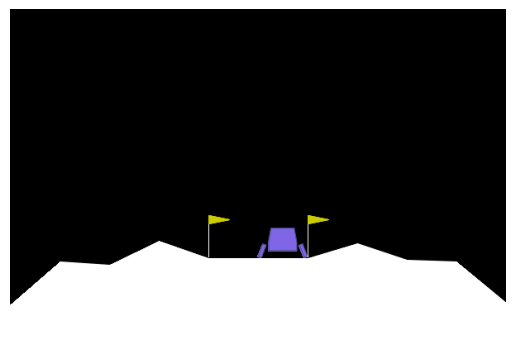

In [6]:
ll_classical_ppo.evaluate()

In [7]:
# 2. Qubit PPO
ll_config["actor_intermediate_dim"] = 4
mode = "qubit"
train = False # ~ 4 hours if True

with MemoryTracker() as ll_qubit_stats:
    ll_qubit_ppo = PPO(
        AutoEncoderClass=AutoEncoder, 
        ActorClass=ActorQubitNN, 
        CriticClass=CriticNN, 
        env=lunarlander_env,
        env_name=env_name,
        env_config=ll_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=ll_qubit_stats
        )

    if train:
        qrl_results = ll_qubit_ppo.run()
    else:
       load_weights(results_folder, ll_qubit_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading models' weights


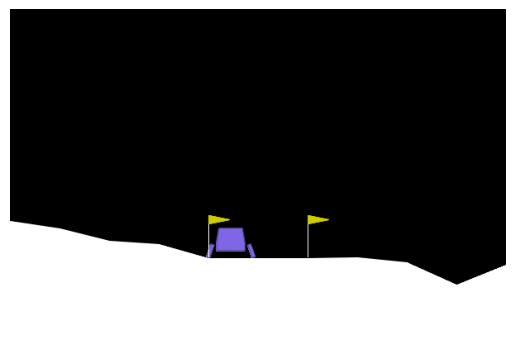

In [8]:
ll_qubit_ppo.evaluate()

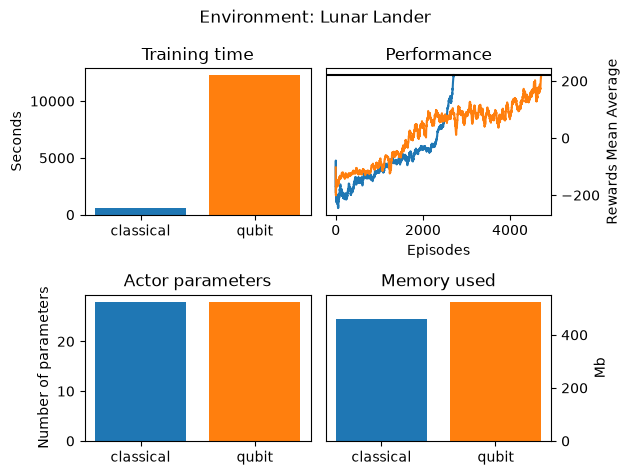

In [9]:
plot_results(env_name, qrl_results.get(env_name, {}), ll_config["mean_reward_stop"])

## 3 - The Maze environment
___

In this custom environment, the agent (the blue square) learns to navigate a maze to find the exit (the green square). 

<div align="center">
<img src="images/qrl_demo_maze.gif" width="500"/>
</div>

At each step, the agent gets a 96x96 RGB image as observations. It can then choose between 4 actions: go up, go down, go right or go left.

The reward is +1 when the agent gets to the exit, -1 if it hits a wall. The episode ends if the agent hits a wall, gets to the exit or if it spent too much time exploring (if it has moved more times than there are squares in the grid). 

The code for this environment can be found here: [MazeEnvironment.py](MazeEnvironment.py).

In [10]:
# Create the custom Maze environment
grid_size = 6
img_size = 64
maze_env = Maze(grid_size=grid_size, img_size=img_size)
maze_env.reset(seed=seed)
maze_env.action_space.seed(seed)
maze_env.observation_space.seed(seed)

42

## 4 - Convolutional Neural Networks (CNNs)
___

The first notebook introduced AutoEncoders, as well as classical and qubit-based Proximal Policy Optimization (PPO) agents.

For the Maze environment however, since the input is an image, we will use a Convolutional Neural Network (CNN) as the first part of the AutoEncoder.

Convolutional layers apply small filters across the image to detect local patterns such as edges, corners, and shapes while preserving the spatial relationships between pixels. By applying multiple convolutional layers, the model learns to encode increasingly abstract visual features.

<div align="center">
<img src="images/qrl_demo_cnn.png" width="1000"/>
</div>

In this notebook, the CNN part of the AE is a pretrained ResNet18 model. We pretrain the bottleneck and decoder parts of the AE on images from the Maze environment. Then, the convolutional layers of the decoder are frozen as well for the actual PPO training, leaving only the linear layers, which helps training stability.

In [ ]:
class ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        self.features = nn.Sequential(*list(backbone.children())[:-2])

        self.output_size = 2048

    def forward(self, x):
        x = self.features(x.permute(0, 3, 1, 2))

        return torch.flatten(x, 1)
    
class ResNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 512, 2, 2)
        x = self.decoder(x)
        return x.permute(0, 2, 3, 1)

class CriticCNN(nn.Module):
    def __init__(self, input_shape, intermediate_dim, output_dim):
        super().__init__()
        self.cnn = ResNetEncoder()
        self.nn = CriticNN(self.cnn.output_size, intermediate_dim, output_dim)

    def forward(self, x):
        x = self.cnn(x)
        x = self.nn(x)
        return x

class ConvolutionalAE(nn.Module):
    def __init__(self, input_shape, parameters):
        super().__init__()
        self.image_shape = input_shape
        self.cnn_encoder = ResNetEncoder()
        self.cnn_decoder = ResNetDecoder()
        self.encoder = nn.Sequential(
            self.cnn_encoder,
            EncoderDecoderNN(self.cnn_encoder.output_size, parameters["ae_hidden_dim"], parameters["ae_output_dim"])
        )
        self.decoder = nn.Sequential(
            EncoderDecoderNN(parameters["ae_output_dim"], parameters["ae_hidden_dim"], self.cnn_encoder.output_size),
            self.cnn_decoder
        )
        self.hyperparameters = parameters

    def calculate_image_weights(self, x):
        # Since the image is sparse, we give more weight to the agent and exit
        weights = torch.ones(x.shape[:-1], device=x.device)
        white = (x.mean(-1) > 0.95)
        weights[white] = 1.0
        black = (x.mean(-1) < 0.05)
        weights[black] = 3.0
        blue = (
            (x[...,2] > 0.8) &
            (x[...,0] < 0.2) &
            (x[...,1] < 0.2)
        )
        weights[blue] = 100.0
        green = (
            (x[...,1] > 0.8) &
            (x[...,0] < 0.2) &
            (x[...,2] < 0.2)
        )
        weights[green] = 100.0
        weights = weights.unsqueeze(-1)
        return weights
    
    def pre_train(self, save_path, env, device):
        best_val_loss = np.inf
        optimizer = optim.Adam(self.parameters())
        epochs = self.hyperparameters["ae_pretrain_epochs"]
        batch_size = self.hyperparameters["ae_pretrain_batchsize"]

        # Training examples
        states_deque = deque([], maxlen=self.hyperparameters["ae_pretrain_n_examples"])
        for _ in range(self.hyperparameters["ae_pretrain_n_examples"]):
            state, _ = env.reset()
            state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            states_deque.append(state)
        states = torch.cat(list(states_deque))

        # Visual validation examples
        val_states = []
        for curriculum_level in self.hyperparameters["curriculum_levels"][:-1]:
            state, _ = env.reset(curriculum_level=curriculum_level)
            state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            val_states.append(state)
        val_states = torch.cat(val_states)

        # Training
        for epoch in range(epochs):
            mean_training_loss = 0
            perm = torch.randperm(len(states))
            shuffled = states[perm]
            for i_train in range(0, len(states) // batch_size + 1, batch_size):
                x = shuffled[i_train:i_train+batch_size]
                x_hat = self.decoder(F.tanh(self.encoder(x)))

                weights = self.calculate_image_weights(x)
                train_loss = (F.mse_loss(x_hat, x)*weights).mean()

                optimizer.zero_grad()
                train_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
                optimizer.step()

                mean_training_loss += train_loss.item()
            mean_training_loss /= (i_train+1)

            mean_val_loss = 0
            xs = []
            x_hats = []
            for i_val in range(val_states.shape[0]):
                x = val_states[i_val].unsqueeze(0)
                x_hat = self.decoder(F.tanh(self.encoder(x)))
                xs.append(x)
                x_hats.append(x_hat)

                weights = self.calculate_image_weights(x)
                val_loss = (F.mse_loss(x_hat, x)*weights).mean()

                mean_val_loss += val_loss.item()
            mean_val_loss /= (i_val+1)

            # Save the model
            if mean_val_loss < best_val_loss:
                best_val_loss = mean_val_loss
                torch.save(self.state_dict(), save_path)

                plt.figure()
                outer = gridspec.GridSpec(nrows=3, ncols=3)
                axes = []
                for row in range(3):
                    for col in range(3):
                        inner = gridspec.GridSpecFromSubplotSpec(nrows=1, ncols=2, subplot_spec=outer[row, col], wspace=0)
                        axes += [plt.subplot(cell) for cell in inner]
                
                for i_val in range(val_states.shape[0]):
                    x = xs[i_val]
                    x_hat = x_hats[i_val]

                    x = x.detach().cpu().numpy()
                    x = (x*255.0).astype(np.uint8)
                    x_hat = x_hat.detach().cpu().numpy()
                    x_hat = (x_hat*255.0).astype(np.uint8)

                    axes[i_val*2].imshow(x[0])
                    axes[i_val*2].set_xticks([])
                    axes[i_val*2].set_yticks([])
                    axes[i_val*2+1].imshow(x_hat[0])
                    axes[i_val*2+1].set_xticks([])
                    axes[i_val*2+1].set_yticks([])

                title = f"Epoch {epoch+1}/{epochs}: training loss = {mean_training_loss:.7f}, val loss = {mean_val_loss:.7f}"
                plt.suptitle(title)
                plt.tight_layout()
                plt.show()

            if (epoch+1)%self.hyperparameters["ae_reg_epochs"] == 0:
                # Regenerate part of the training examples for better generalization
                percent = 0.1
                for _ in range(int(self.hyperparameters["ae_pretrain_n_examples"]*percent)):
                    state, _ = env.reset()
                    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                    states_deque.append(state)
                states = torch.cat(list(states_deque))
                #print(f"Epoch {epoch+1}/{epochs}: regenerated {percent*100}% of training dataset")


## 5 - Modified PPO for Maze
___

We modify the PPO class a bit for the Maze environment:

- First, to add the pre-training of the ConvolutionalAE. 

- Also, we use curriculum learning to improve learning speed. Curriculum learning allows learning in increasingly hard examples, to build a strong foundation before moving to harder problems. In the lower levels there are no inner walls, and we progressively add more walls.

- Finally, we also modify the reward: the overall reward tells us whether the agent found the exit or hit a wall. The distance reward lets the models know whether they got closer to the exit or not after each step. 

In [12]:
class MazePPO(PPO):
    def __init__(self, *args, train_ae, **kwargs):
        super().__init__(*args, **kwargs)

        # Pre-train the autoencoder before PPO
        autoencoder_path = os.path.join(self.results_folder, "cnn_ae.pt")
        if train_ae:
            print("\nPre-training ConvolutionalAE")
            self.autoencoder.pre_train(autoencoder_path, self.env, self.device)
        elif os.path.exists(autoencoder_path):
            print("\nLoading ConvolutionalAE weights")
            self.autoencoder.load_state_dict(torch.load(autoencoder_path, weights_only=True, map_location=self.device))
        else:
            print("\nCan't load ConvolutionalAE weights")

        self.critic.cnn.load_state_dict(self.autoencoder.cnn_encoder.state_dict())
        
        for p in self.autoencoder.cnn_encoder.parameters():
            p.requires_grad = False

        for p in self.autoencoder.cnn_decoder.parameters():
            p.requires_grad = False

        for p in self.critic.cnn.parameters():
            p.requires_grad = False
        
        self.autoencoder.cnn_encoder.eval()
        self.autoencoder.cnn_decoder.eval()
        self.critic.cnn.eval()

    def run(self):
        print(f"\nPPO training")
        training_start = datetime.datetime.now()
        mean_rewards = []
        total_timesteps = 0
        start = datetime.datetime.now()
        for cl, curriculum_level in enumerate(self.config["curriculum_levels"]):
            print(f"\nCurriculum level {cl+1}/{len(self.config['curriculum_levels'])}")
            self.optimizer = optim.Adam(
                list(filter(lambda p: p.requires_grad, self.autoencoder.parameters())) +
                list(self.actor.parameters()) +
                list(filter(lambda p: p.requires_grad, self.critic.parameters())),
                lr=self.config["lr"]
            )
            rewards = []
            mean_reward = 0
            while len(rewards) < self.config["mean_reward_lookback"] or mean_reward < self.config["mean_reward_stop"]:
                state, _ = self.env.reset(curriculum_level = curriculum_level)
                cumulative_reward = 0
                for _ in count():
                    total_timesteps += 1

                    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
                    with torch.no_grad():
                        encoded_state = F.tanh(self.autoencoder.encoder(state))
                        action, action_log_probability, _, state_value = self.apply_policy(state, encoded_state)

                    old_pos = tuple(self.env.agent_position)
                    next_state, reward, terminated, truncated, _ = self.env.step(action.item())
                    new_pos = tuple(self.env.agent_position)
                    done = terminated or truncated

                    if done:
                        distance_reward = reward
                    else:
                        distance_reward = self.env.distance_map[old_pos[0], old_pos[1]] - self.env.distance_map[new_pos[0], new_pos[1]]

                    self.buffer.add(state.detach(), action.detach(), action_log_probability.detach(), state_value.detach(), distance_reward, done)

                    cumulative_reward += reward

                    state = next_state

                    if total_timesteps % self.steps_update_frequency == 0:
                        self.optimize_models()

                    if total_timesteps % self.config["print_steps_frequency"] == 0:
                        print(f"\nStep {total_timesteps}: mean reward = {mean_reward:.2f} ({datetime.datetime.now()-start})")
                        start = datetime.datetime.now()
                    

                    if done:
                        break

                rewards.append(cumulative_reward)
                mean_reward = np.mean(rewards[-self.config["mean_reward_lookback"]:])
                mean_rewards.append(mean_reward)
                training_time = datetime.datetime.now()-training_start

                results = { 
                    "training_time": training_time.total_seconds(), 
                    "mean_rewards": mean_rewards, 
                    "parameters": self.n_parameters, 
                    "memory": self.memory_stats.peak_rss_mb 
                }
                qrl_results = save_results(self.results_filepath, self.env_name, self.mode, results)

        print(f"\nTotal training time: {training_time}")
        return qrl_results

## 6 - Results on Maze
___

In [13]:
env_name = "Maze"
m_config = {
    "ae_hidden_dim": 128, "ae_output_dim": 16, 
    "ae_pretrain_epochs": 20000, "ae_reg_epochs": 1000, "ae_pretrain_n_examples": 100000, "ae_pretrain_batchsize": 128,
    "critic_intermediate_dim": 128,
    "minibatch_size": 128, "lr": 1e-4,
    "K": 8, "episode_update_frequency": 20, "mean_reward_lookback": 30, "mean_reward_stop": 0.9,
    "curriculum_levels": [
        (0, 0, 0, 1), # Level 1
        (0, 0, 0, 3), # Level 2
        (0, 0, 0, 5), # Level 3
        (1, 1, 4, 3), # Level 4
        (1, 1, 4, 5), # Level 5
        (2, 2, 8, 3), # Level 6
        (2, 2, 8, 5), # Level 7
        (3, 3, 8, 3), # Level 8
        (3, 3, 8, 5), # Level 9
        None],        # Level 10
    "gamma": 0.99, "lambda": 0.95, "epsilon": 0.2, "entropy_coeff": 0.01, "print_steps_frequency": 1000000
    }
custom_obs_shape = (img_size, img_size, 3)


Pre-training ConvolutionalAE


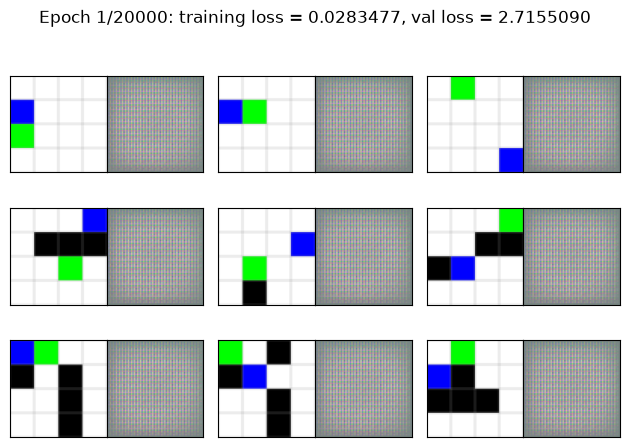

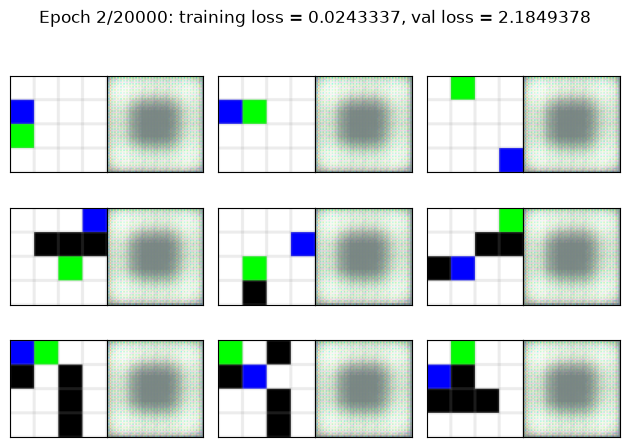

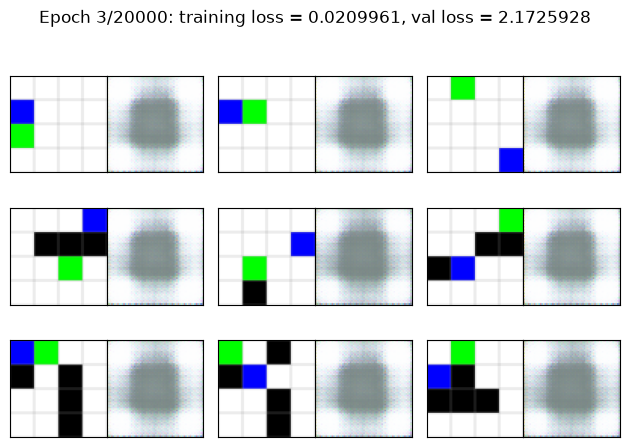

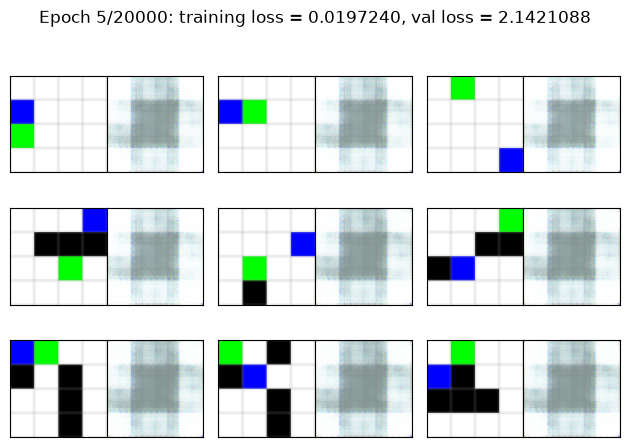

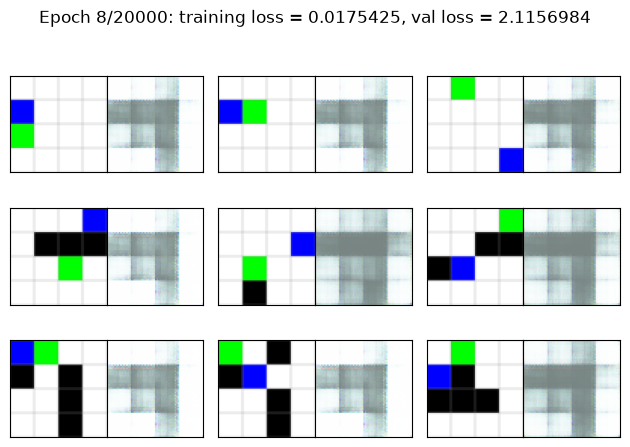

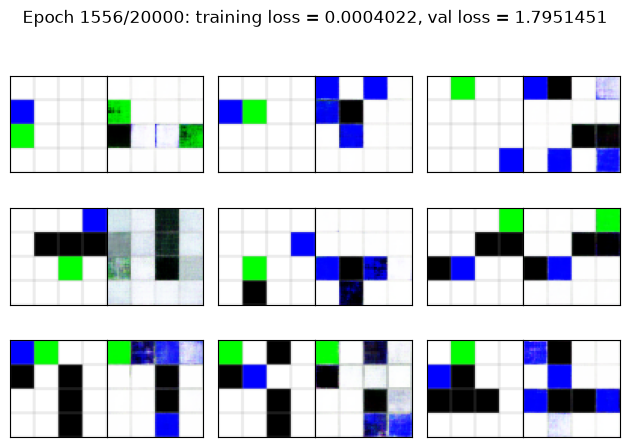

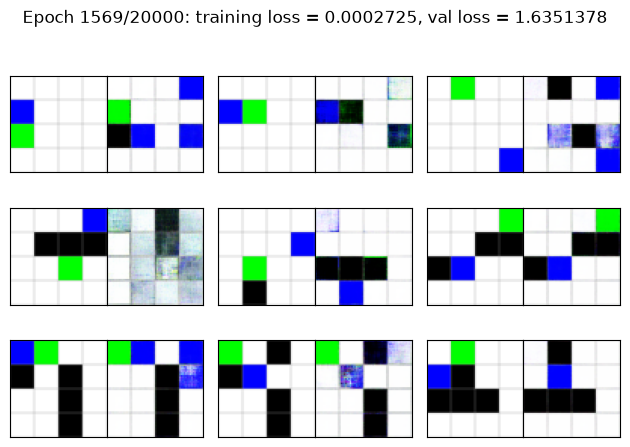

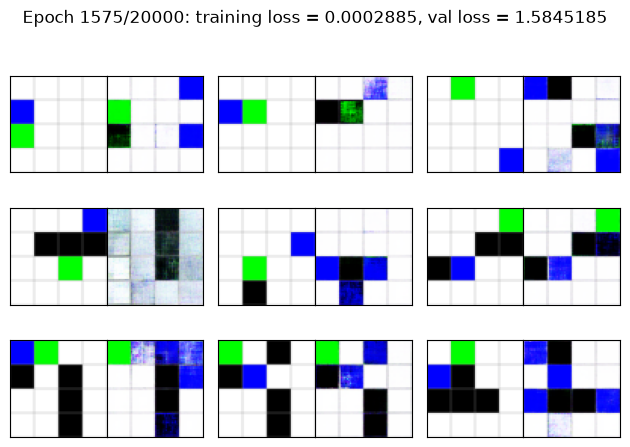

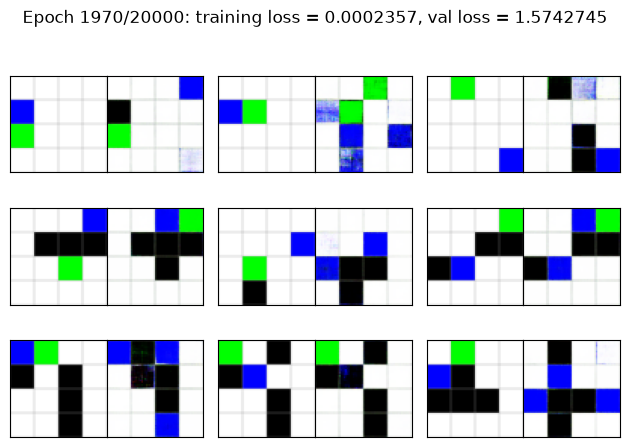

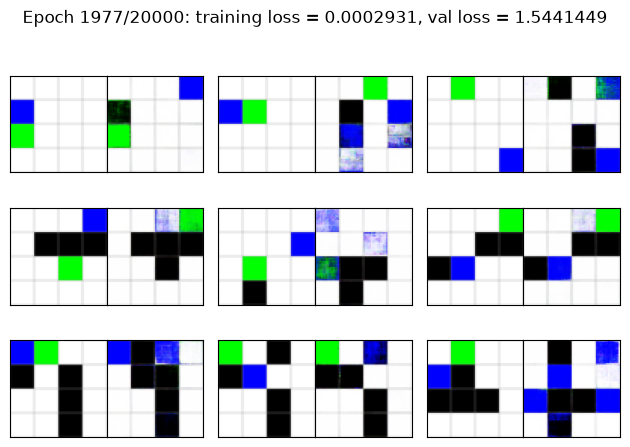

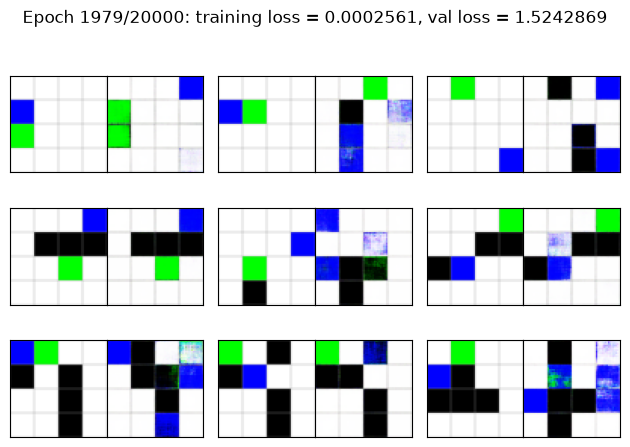

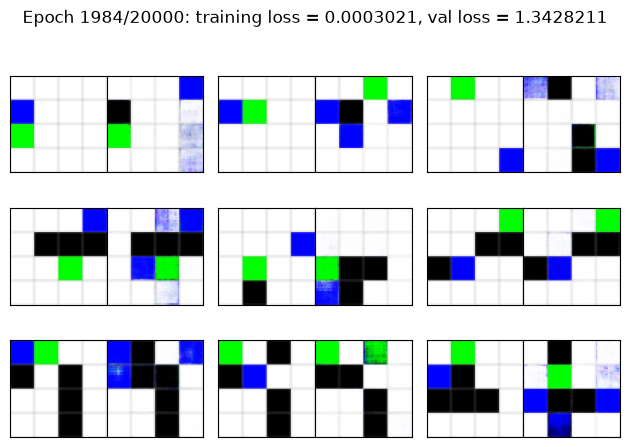

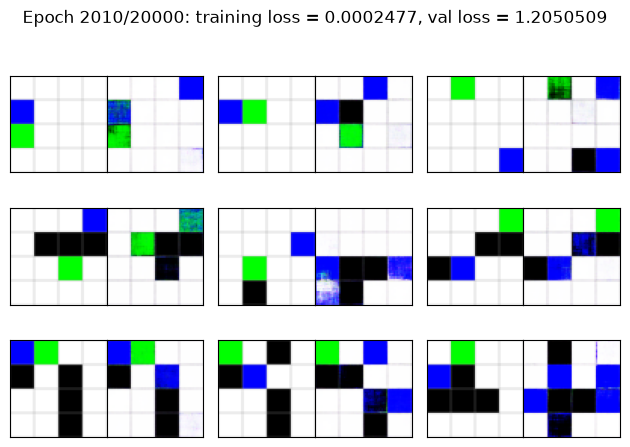

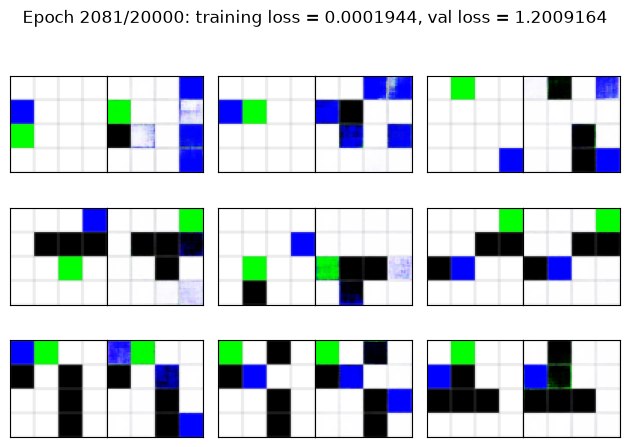

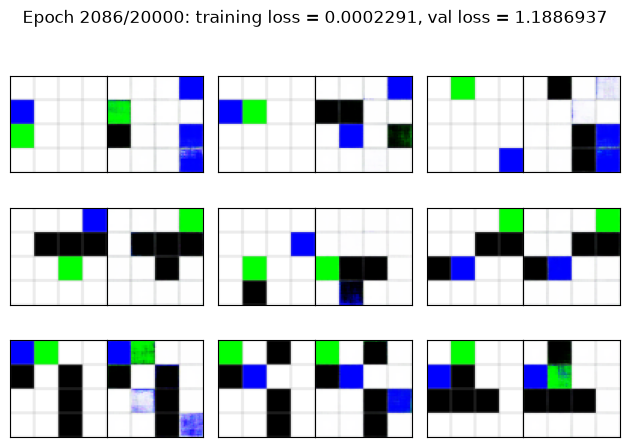

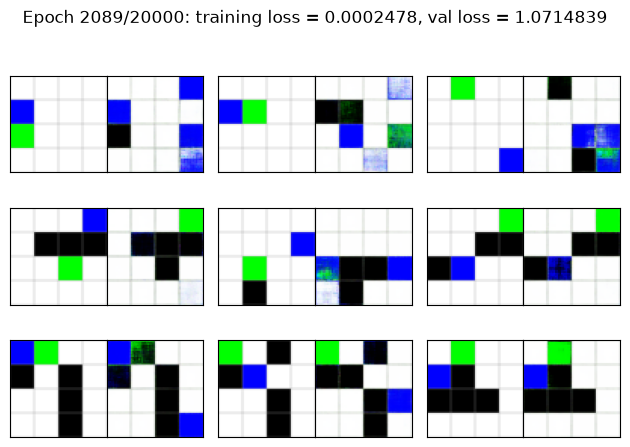

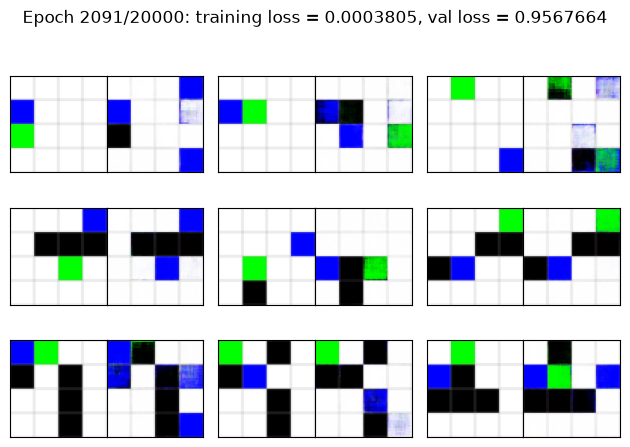

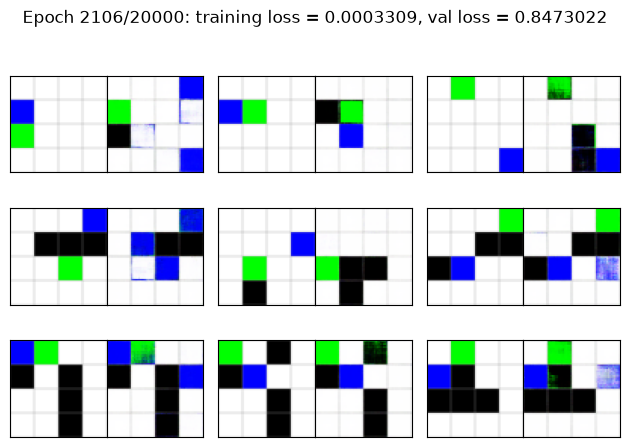

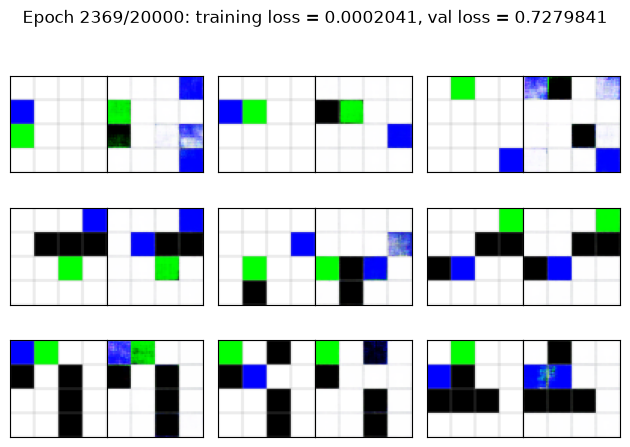

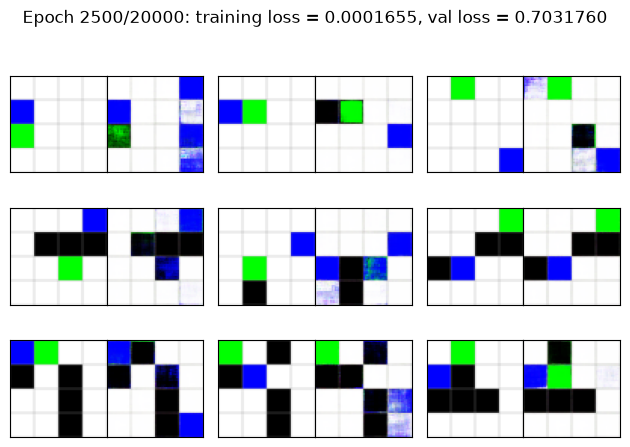

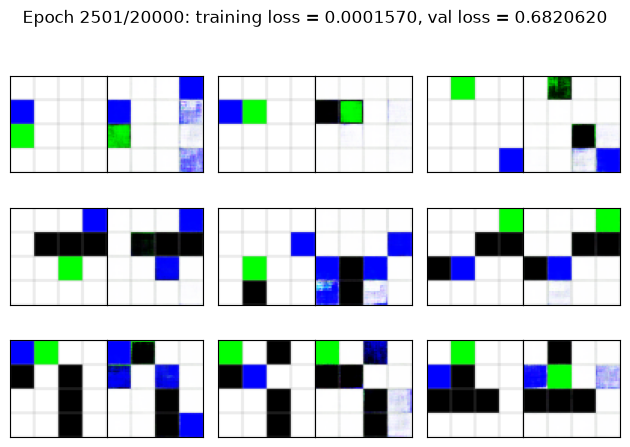

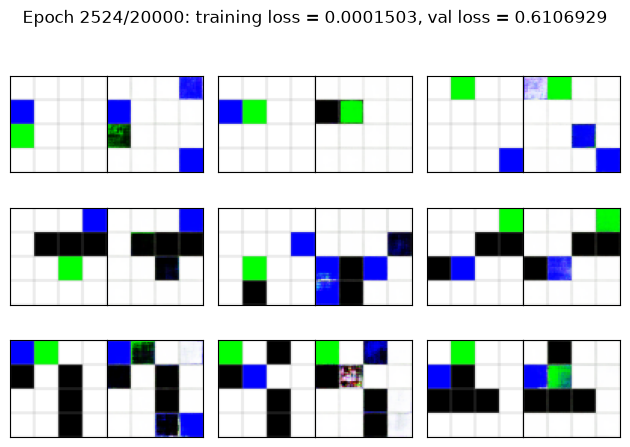

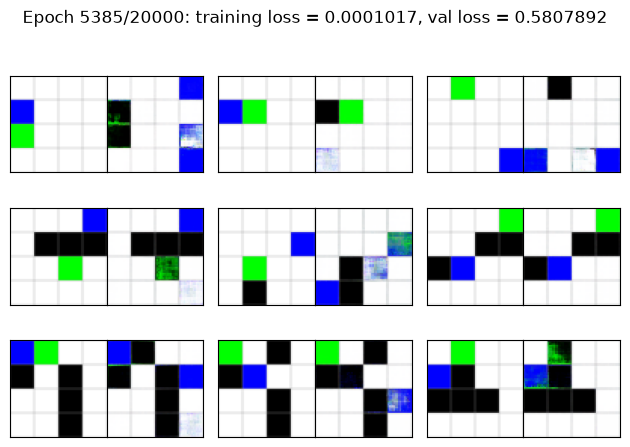

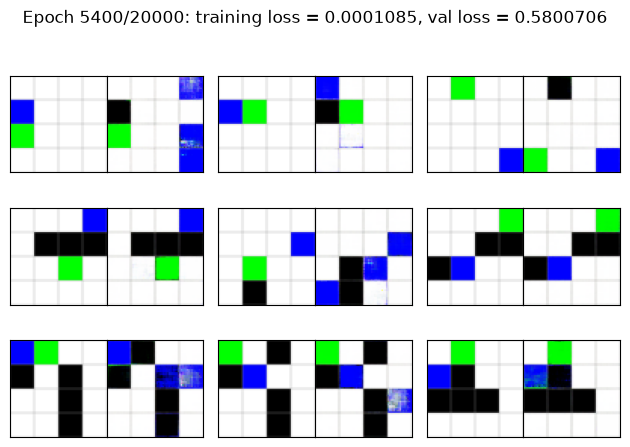

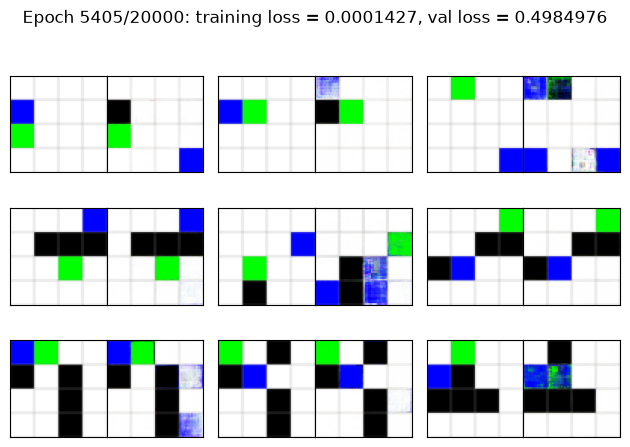

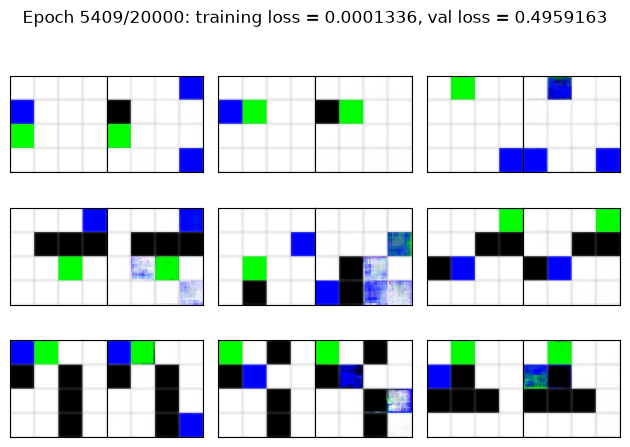

RuntimeError: [enforce fail at inline_container.cc:745] . open file failed with error code: 1224

In [14]:
# 1. Classical PPO
m_config["actor_intermediate_dim"] = 4
mode = "classical"
train = True # ~ 3 days if True
train_ae = True # ~ 12 hours if True

with MemoryTracker() as m_classical_stats:
    m_classical_ppo = MazePPO(
        AutoEncoderClass=ConvolutionalAE, 
        ActorClass=ActorNN, 
        CriticClass=CriticCNN, 
        env=maze_env,
        env_name=env_name,
        env_config=m_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=m_classical_stats,
        custom_obs_shape=custom_obs_shape,
        train_ae = train_ae
        )

    if train:
        qrl_results = m_classical_ppo.run()
    else:
       load_weights(results_folder, m_classical_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))

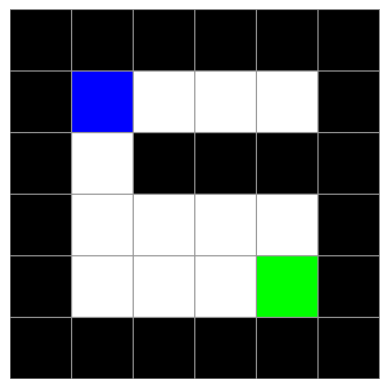

In [ ]:
m_classical_ppo.evaluate()

In [ ]:
# 2. Qubit PPO
m_config["actor_intermediate_dim"] = 5
mode = "qubit"
train = True # ~ 6 days if True
train_ae = False # ~ 12 hours if True

with MemoryTracker() as m_qubit_stats:
    m_qubit_ppo = MazePPO(
        AutoEncoderClass=ConvolutionalAE, 
        ActorClass=ActorQubitNN, 
        CriticClass=CriticCNN, 
        env=maze_env,
        env_name=env_name,
        env_config=m_config, 
        mode=mode,
        device=device,
        results_folder=results_folder,
        results_filename=results_filename,
        memory_stats=m_qubit_stats,
        custom_obs_shape=custom_obs_shape,
        train_ae = train_ae
        )

    if train:
        qrl_results = m_qubit_ppo.run()
    else:
       load_weights(results_folder, m_qubit_ppo, env_name, mode, device)
       qrl_results = load_results(os.path.join(results_folder, results_filename))


Loading ConvolutionalAE weights

Loading models' weights


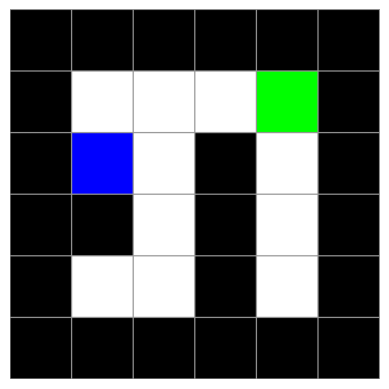

In [ ]:
m_qubit_ppo.evaluate()

Results for classical (Maze) don't exist !
Results for qubit (Maze) don't exist !


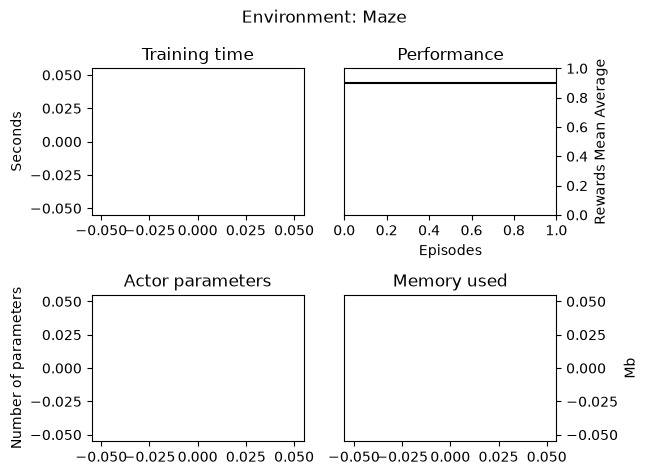

In [ ]:
plot_results(env_name, qrl_results.get(env_name, {}), m_config["mean_reward_stop"])

## 7 - Conclusions & follow-up
___

With bigger environments, the training time of simulated quantum models is becoming a real limitation. The constraint on parameters size is also limiting the progress of both types of models. Both methods reached the expected performance again though, with rather similar memory resources.

You can again play around with the configuration and try using other values for actor_intermediate_dim to see how the results change.

In the next notebook, we'll try using a photonic-based PPO on the three environments.
